# Explorary Data Analysis

## Package Import & Path Settings

In [1]:
import os
import pandas as pd
from pandas import DataFrame
import numpy as np
import matplotlib.pyplot as plt
import json
import hashlib
from pathlib import Path
from collections import defaultdict


from PIL import Image, UnidentifiedImageError

# pytorch
from torchvision.datasets import ImageFolder
from torch.utils.data import Subset

# data split
from sklearn.model_selection import train_test_split

# preprocessing & structure
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.compose import TransformedTargetRegressor
from sklearn.preprocessing import FunctionTransformer

# baseline models
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, mean_absolute_error, mean_squared_error

# others
from concurrent.futures import ThreadPoolExecutor

# path settings
from src import MODELS_DIR, PARAMS_PATH, SEED, PET_IMAGES_DIR, get_device
DEVICE = get_device()
print(f'Device: {DEVICE}')
print(f'MODELS_DIR: {MODELS_DIR}')
print(f'PARAMS_PATH: {PARAMS_PATH}')
print(f'SEED: {SEED}')
print(f'PET_IMAGES_DIR: {PET_IMAGES_DIR}')

label = {0:'cat', 1:'dog'}


Device: cuda
MODELS_DIR: D:\Coding Stuff\Python\kaggle\kaggle-image-classification-cats_dogs\outputs\models
PARAMS_PATH: D:\Coding Stuff\Python\kaggle\kaggle-image-classification-cats_dogs\outputs\params
SEED: 37
PET_IMAGES_DIR: D:\Coding Stuff\Python\kaggle\kaggle-image-classification-cats_dogs\data\raw\PetImages


## Data Loading

In [6]:

def get_meta(path):
    with Image.open(path) as im:
        return im.mode, im.size[0], im.size[1]

def is_valid_image(path: str) -> bool:
    try:
        # verify() checks file integrity without fully decoding pixel data
        with Image.open(path) as im:            
            im.load()
        return True
    except (UnidentifiedImageError, OSError, IOError):
        return False

def sha256_file(path: Path, chunk_size: int = 1024 * 1024) -> str:
    # Hash file content to detect exact duplicates
    h = hashlib.sha256()
    with path.open("rb") as f:
        for chunk in iter(lambda: f.read(chunk_size), b""):
            h.update(chunk)
    return h.hexdigest()

def find_dups_size_hash(
    root_dir: Path,
    abs_paths: list[str],
    max_workers: int | None = None,
) -> tuple[dict[str, list[str]], list[str], list[str]]:
    """
    Returns:
      - dup_groups: {sha256: [rel_paths...]} only groups with len>1
      - dup_files_list: flat list of duplicate rel_paths to drop (keeps 1 per group)
      - keep_files_list: flat list of kept rel_paths (unique representatives)
    """
        
    if max_workers is None:
        max_workers = min(32, (os.cpu_count() or 8) + 4)

    # 1) Bucket by file size (cheap)
    size_buckets = defaultdict(list)
    for ap in abs_paths:
        p = Path(ap)
        try:
            size_buckets[p.stat().st_size].append(ap)
        except OSError:
            # If file is missing/unreadable, skip here (bad list should catch it)
            pass

    # Only hash buckets with collisions
    candidates = []
    for _, bucket in size_buckets.items():
        if len(bucket) > 1:
            candidates.extend(bucket)

    # 2) Hash only collision candidates
    def _hash_abs(ap: str) -> tuple[str | None, str]:
        p = Path(ap)
        try:
            return sha256_file(p), ap
        except Exception:
            return None, ap

    hash_to_paths = defaultdict(list)
    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        for h, ap in ex.map(_hash_abs, candidates):
            if h is not None:
                hash_to_paths[h].append(ap)
    
    rel_paths = list(map(lambda x: str(Path(x).relative_to(root_dir)), abs_paths))
    
    dup_groups = {h: ps for h, ps in hash_to_paths.items() if len(ps) > 1}

    # 3) Build drop/keep lists (keep one representative per dup group)
    dup_set = set()
    keep_set = set(rel_paths)  # start with all, then drop duplicates

    for h, ps in dup_groups.items():
        ps_sorted = sorted(ps)
        keep_one = ps_sorted[0]
        keep_set.add(keep_one)
        for rp in ps_sorted[1:]:
            dup_set.add(rp)
            if rp in keep_set:
                keep_set.remove(rp)

    dup_files_list = sorted(dup_set)
    keep_files_list = sorted(keep_set)

    return dup_groups, dup_files_list, keep_files_list


ds = ImageFolder(PET_IMAGES_DIR)


### Corrupted Files Handling

In [3]:
try:    
    with open(PET_IMAGES_DIR / 'bad_files.json') as f:
        bad_files = json.load(f)
        bad_path_list = bad_files['bad_files_list']
        tot_file_num = bad_files['total_file_num']
        bad_file_cnt = len(bad_path_list)
        if tot_file_num != len(ds):
            raise ValueError("total_file_num mismatch")

except (FileNotFoundError, json.JSONDecodeError, KeyError, ValueError):
    print('Bad file list needs update, looping through the dataset...', end='')
    with ThreadPoolExecutor() as ex:
        bad_idx = [i for i, valid in enumerate(ex.map(is_valid_image, (p for p, _ in ds.samples))) if not valid]
        ds_bad = Subset(ds, bad_idx)
        bad_file_cnt = len(ds_bad)
        bad_path_list = []
    print('finished')
    if len(ds_bad.indices) > 0:
        print('Found bad files in the following path:')
        for i in ds_bad.indices:
            bad_path = Path(ds_bad.dataset.samples[i][0]).relative_to(PET_IMAGES_DIR)
            bad_path_list.append(str(bad_path))
            print(bad_path)

    dump_dict  = {'bad_files_list':bad_path_list, 'total_file_num':len(ds)}

    with open(PET_IMAGES_DIR / 'bad_files.json', 'w') as f:
        json.dump(dump_dict, f)

bad_path_set = set(bad_path_list)

print(f"Total File Count: {len(ds)}, Bad: {bad_file_cnt}, Good: {len(ds) - bad_file_cnt}")

Total File Count: 25000, Bad: 2, Good: 24998


### Duplicated Files Handling

1. Sort images by file size
2. Calculate the images in the same size bin, if hash value collides then they may be duplicates
3. Store the results for caching and diagnosis

In [18]:
dup_groups_path = PET_IMAGES_DIR / "duplicate_groups_exact.json"
dup_list_path = PET_IMAGES_DIR / "duplicate_files_list.json"
unique_keep_path = PET_IMAGES_DIR / "unique_keep_files_list.json"

try:
    with open(dup_groups_path) as f:
        dup_groups = json.load(f)  # hash -> [rel_paths...]
    with open(dup_list_path) as f:
        dup_files_list = json.load(f)["duplicate_files_list"]
    with open(unique_keep_path) as f:
        unique_keep_list = json.load(f)["unique_keep_files_list"]

    # Optional consistency check
    if bad_files.get("total_file_num", len(ds)) != len(ds):
        raise ValueError("total_file_num mismatch for duplicate cache")
except (FileNotFoundError, json.JSONDecodeError, KeyError, ValueError, UnboundLocalError):
    print('Duplicate list needs update, hashing good files...', end='')

    # Collect indices of "good" files (not in bad list)
    good_indices = []
    good_samples = []
    for i, (p_str, y) in enumerate(ds.samples):
        rel = str(Path(p_str).relative_to(PET_IMAGES_DIR))
        if rel in bad_path_set:
            continue
        good_indices.append(i)
        good_samples.append((p_str, y))

    # Hash in parallel
    # with ThreadPoolExecutor() as ex:
    #     future = ex.submit(find_dups_size_hash, PET_IMAGES_DIR, [p for p, _ in good_samples])
    #     dup_groups, dup_files_list, unique_keep_list = future.result()
    abs_paths = [p_str for (p_str, _y) in good_samples]
    dup_groups, dup_files_list, unique_keep_list = find_dups_size_hash(PET_IMAGES_DIR, abs_paths)

    print('finished')

    # Dump caches
    with open(dup_groups_path, "w") as f:
        json.dump(dup_groups, f, indent=2)

    with open(dup_list_path, "w") as f:
        json.dump({"duplicate_files_list": dup_files_list, "total_file_num": len(ds)}, f, indent=2)

    with open(unique_keep_path, "w") as f:
        json.dump({"unique_keep_files_list": unique_keep_list, "total_file_num": len(ds)}, f, indent=2)


Plot the duplicates and output as image for examination

In [ ]:
for key, group in dup_groups.items():
    fig, ax = plt.subplots(1, len(group))
    for i, p in enumerate(group):
        img = Image.open(p)
        ax[i].imshow(img)
        rel_path = Path(p).relative_to(PET_IMAGES_DIR)
        ax[i].set_title(f'{rel_path}, format: {img.mode}', fontsize=10)
        ax[i].set_axis_off()
    fig.tight_layout()
    fig.savefig(PET_IMAGES_DIR / f'{key}.jpg')
    plt.close(fig)

: 

: 

A group has images with different labels, it is acutally an error image that was mislabeled.

![Error Cat](a640a1af929477cff207c037097a6289f1493b40bbdb581b0508cb4d7e4616e7.jpg)

Another error image

![Incorrect Image](397243846bc107d7fce1727d34c552dc8d2520700f20dbd2e344d9b37bbd7131.jpg)

## Image Files Analysis

d:\Coding Stuff\Python\kaggle\kaggle-image-classification-cats_dogs\.venv\Lib\site-packages\PIL\TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


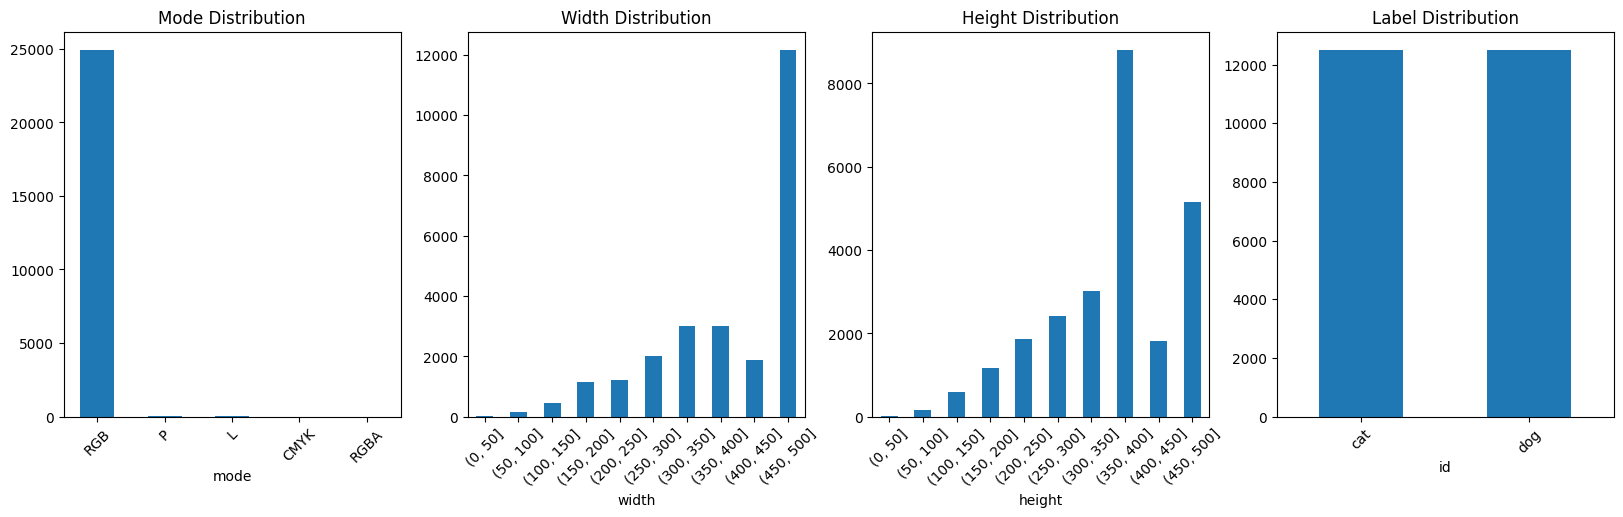

In [52]:
bad_path_set = set(bad_path_list)
ds.samples = [(p, y) for (p, y) in ds.samples if str(Path(p).relative_to(PET_IMAGES_DIR)) not in bad_path_set]
ds.imgs = ds.samples
ds.targets = [y for _, y in ds.samples]
ds_stat_df = pd.DataFrame(ds.samples, columns=['path', 'id'])
    
with ThreadPoolExecutor() as ex:
    modes, widths, heights = zip(*ex.map(get_meta, ds_stat_df['path'].tolist()))

ds_stat_df["mode"] = modes
ds_stat_df["width"] = widths
ds_stat_df["height"] = heights

def closest_bin(n, unit):
    return (n // unit) * unit

fig, ax = plt.subplots(1, 4, figsize=(20, 5))
ds_stat_df['mode'].value_counts().plot(kind='bar', ax=ax[0])
size_unit = 50
width_bins = range(closest_bin(ds_stat_df['width'].min(), size_unit), closest_bin(ds_stat_df['width'].max(), size_unit) + size_unit, size_unit)
height_bins = range(closest_bin(ds_stat_df['height'].min(), size_unit), closest_bin(ds_stat_df['height'].max(), size_unit) + size_unit, size_unit)
pd.cut(ds_stat_df['width'], width_bins, duplicates='drop').value_counts().sort_index().plot(kind='bar', ax=ax[1])
pd.cut(ds_stat_df['height'], height_bins, duplicates='drop').value_counts().sort_index().plot(kind='bar', ax=ax[2])
ds_stat_df['id'].map(label).value_counts().plot(kind='bar', ax=ax[3])
ax[0].set_title('Mode Distribution')
ax[1].set_title('Width Distribution')
ax[2].set_title('Height Distribution')
ax[3].set_title('Label Distribution')

for a in ax:
    a.tick_params(axis='x', rotation=45)


## Observations

1. `RGB` is the dominate image format, and there are some other file formats in small number. `PIL` can handle all of them, and they should be converted to `RGB` in the preprocess pipeline.
    - **RGB**: True color mode with 3 channels (Red, Green, Blue), each 8 bits, representing full-color images without transparency.
    - **P**: Palette mode with 8-bit pixels, using a color palette to map to other modes like RGB; efficient for images with limited colors.
    - **L**: Luminance mode with 8-bit grayscale pixels, representing shades from black (0) to white (255).
    - **RGBA**: True color with transparency, 4 channels (Red, Green, Blue, Alpha), where Alpha controls opacity.
    - **CMYK**: Color separation mode with 4 channels (Cyan, Magenta, Yellow, Key/Black), commonly used in printing.
2. Image dimension varies between samples, but most of them are within the range of 300-500 x 300-500 px.
3. The label distributio is balanced in the dataset.

In [ ]:
def rgba_to_rgb_with_bg(img: Image.Image, bg=(255, 255, 255)) -> Image.Image:
    if img.mode != "RGBA":
        img = img.convert("RGBA")
    background = Image.new("RGBA", img.size, bg + (255,))
    composed = Image.alpha_composite(background, img)
    return composed.convert("RGB")

Random draw from the dataset shows that the images inside have different dimensions.

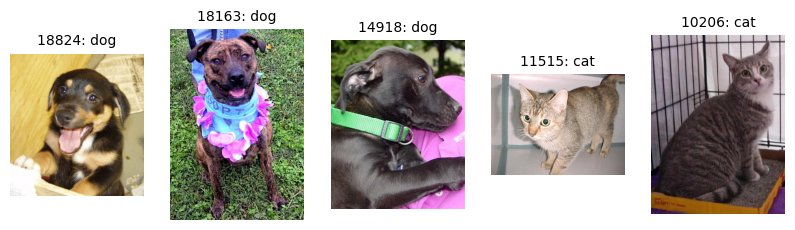

In [47]:
fig, ax = plt.subplots(1, 5, figsize=(10, 30))
for i, idx in enumerate(np.random.randint(0, len(ds) + 1, 5)):
    ax[i].imshow(ds[idx][0])
    ax[i].set_title(f'{idx}: {label[ds[idx][1]]}', fontsize=10)
    ax[i].set_axis_off()
